# Vueling — Transport Activity & Fleet Analysis
### MSc Transport with Data Science · Sustainable Transport · Imperial College London

---
**Scope:** Historical operations (Feb 2025 – Jan 2026) + Fleet & Emissions Forecast (2026 – 2035)  
**Plots:** Section A — Transport Activity & Operations · Section B — Vehicle Fleet  

In [1]:
# ── DEPENDENCIES ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
import warnings
from matplotlib.lines import Line2D
warnings.filterwarnings('ignore')

# Optional: install plotly for Sankey (uncomment if needed)
# !pip install plotly kaleido -q
import plotly.graph_objects as go
import plotly.io as pio

print('Libraries loaded ✓')

import matplotlib.legend as mlegend
_orig_init = mlegend.Legend.__init__
def _bold_legend_title(self, *args, **kwargs):
    _orig_init(self, *args, **kwargs)
    self.get_title().set_fontweight('bold')
mlegend.Legend.__init__ = _bold_legend_title

Libraries loaded ✓


In [2]:
# ── LOAD DATA ─────────────────────────────────────────────────────────────────
# Option A: if df_combined is already in memory from the forecast notebook → skip
# Option B: load from CSV
df_combined = pd.read_csv('../0. Data/1 Year Flight Data/vueling_historical_and_forecast.csv')

df = df_combined.copy()
df['year_month'] = df['year_month'].astype(str).str[:7]
df['year']  = df['year_month'].str[:4].astype(int)
df['month'] = df['year_month'].str[5:7].astype(int)
df['is_forecast'] = df['origin'] == 'forecast'
df.loc[df_combined['year_month']=='2026-01', 'is_forecast'] = True

HIST_CUTOFF = '2026-01'   # last historical month
print(f"Rows: {len(df):,} | Years: {df['year'].min()}-{df['year'].max()}")
df.head(3)

Rows: 663 | Years: 2025-2035


,year_month,aircraft_type_icao,flights_count,total_distance_km_sum,LTO_CO2_sum,CCD_CO2_sum,Total_CO2_sum,pax,origin,year,month,is_forecast
0,2025-02,A319,879.0,749683.97,1907219.04,7189037.60,9.096257e+06,113918.0,historical,2025,2,False
1,2025-02,A320,9564.0,9481592.18,24588374.52,92287951.23,1.168763e+08,1601014.0,historical,2025,2,False
2,2025-02,A320Neo,1181.0,1352121.03,2580827.49,10960397.70,1.354123e+07,197699.0,historical,2025,2,False


In [3]:
# ── DESIGN SYSTEM ────────────────────────────────────────────────────────────

# ── Vueling brand palette ─────────────────────────────────────────────────────
VY = dict(
    yellow     = '#F5C800',   # Vueling primary yellow
    dark       = '#1A1A1A',   # near-black  (text, annotations)
    grey       = '#A0A0A0',   # forecast / muted
    light_grey = '#D6D6D6',   # very light grey for grids / dividers
    white      = '#FFFFFF',
    bg         = '#F5F5F5',   # slide background (keep as-is)
    gold       = '#D4A017',   # warm gold for totals / highlights
    teal       = '#00A3A6',   # accent teal (Boeing / efficiency)
    deep_teal  = '#00657A',   # darker teal
)

# ── Keep IC dict for any remaining references ─────────────────────────────────
IC = dict(
    navy      = '#002147',
    plum      = '#3E1060',
    violet    = '#653098',
    lavender  = '#9B59D0',
    lilac     = '#C9A6E8',
    ice       = '#EEEEEE',   # grid colour — neutral light grey
    deep_teal = VY['deep_teal'],
    teal      = VY['teal'],
    gold      = VY['gold'],
    fog       = VY['bg'],
    ink       = VY['dark'],
    mid       = VY['grey'],
)

# ── Aircraft type colours (Vueling-toned, readable on white/light bg) ─────────
AC_COLORS_A3 = {
    'A319'    : '#BDBDBD',   # light grey   — oldest, retiring
    'A320'    : '#8C8C8C',   # mid grey     — workhorse legacy
    'A321'    : '#4A4A4A',   # dark grey    — larger legacy
    'A320Neo' : '#00A3A6',   # bright teal   — modern Airbus Neo
    'A321Neo' : '#00657A',   # deep teal     — larger Neo
    'B38M'    : '#F5C800',   # Vueling yellow — Boeing newcomer, STANDS OUT
}

AC_LABELS = {
    'A319'    : 'A319',
    'A320'    : 'A320',
    'A321'    : 'A321',
    'A320Neo' : 'A320neo',
    'A321Neo' : 'A321neo',
    'B38M'    : 'B737-8 MAX',
}

# Keep AC_COLORS pointing to same dict for any cells still using it
AC_COLORS = AC_COLORS_A3.copy()

# ── Sequential colormap (grey → yellow) ──────────────────────────────────────
from matplotlib.colors import LinearSegmentedColormap
IC_CMAP = LinearSegmentedColormap.from_list(
    'vueling', [
        '#FFFFFF',   # white        — lowest values
        '#FFF8CC',   # pale yellow  — very light Vueling tint
        '#FFE566',   # soft yellow
        '#F5C800',   # Vueling yellow — mid
        '#C49A00',   # deep golden
        '#7A5F00',   # dark amber
        '#1A1A1A',   # near-black   — highest values
    ])
# ── Global rcParams ───────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor'   : VY['bg'],
    'axes.facecolor'     : VY['bg'],
    'axes.edgecolor'     : VY['light_grey'],
    'axes.linewidth'     : 0.8,
    'axes.grid'          : True,
    'grid.color'         : '#E0E0E0',
    'grid.linewidth'     : 0.6,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'text.color'         : VY['dark'],
    'axes.labelcolor'    : VY['dark'],
    'xtick.color'        : VY['grey'],
    'ytick.color'        : VY['grey'],
    'font.family'        : 'Arial',
    'axes.titleweight'   : 'bold',
    'axes.titlesize'     : 13,
    'axes.labelsize'     : 10,
    'axes.labelweight'   : 'bold',
    'axes.labelpad'      : 8,
    'legend.framealpha'  : 0.95,
    'legend.edgecolor'   : VY['light_grey'],
    'figure.dpi'         : 150,
})

FORECAST_SHADE = dict(color=VY['grey'], alpha=0.06, zorder=0)

def add_forecast_band(ax, x_start, xmax, label=True):
    ax.axvspan(x_start, xmax, **FORECAST_SHADE)
    if label:
        ax.text(x_start + (xmax - x_start)*0.5, ax.get_ylim()[1]*0.97,
                'FORECAST', ha='center', va='top', fontsize=7,
                color=VY['grey'], alpha=0.7, fontstyle='italic', fontweight='bold')

def styled_title(fig, title, subtitle=None, y_pad=0.05):
    y = 0.98 if subtitle else 0.96
    fig.text(0.5, y, title, ha='center', va='top', fontsize=15,
             fontweight='bold', color=VY['dark'])
    if subtitle:
        fig.text(0.5, y - y_pad, subtitle, ha='center', va='top', fontsize=9,
                 color=VY['grey'], fontstyle='italic')

def watermark(fig):
    fig.text(0.99, 0.01, 'Group 9 · Sustainable Transport · Imperial College London',
             ha='right', va='bottom', fontsize=6.5, color=VY['grey'], alpha=0.7)

def style_legend(leg, edge_color=None):
    """Apply consistent Vueling legend styling."""
    edge_color = edge_color or VY['yellow']
    leg.get_frame().set_edgecolor(edge_color)
    leg.get_frame().set_facecolor(VY['bg'])
    leg.get_title().set_fontweight('bold')
    leg.get_title().set_color(VY['dark'])

print('Vueling design system ready ✓')

Vueling design system ready ✓


---
## Section A — Transport Activity & Operations

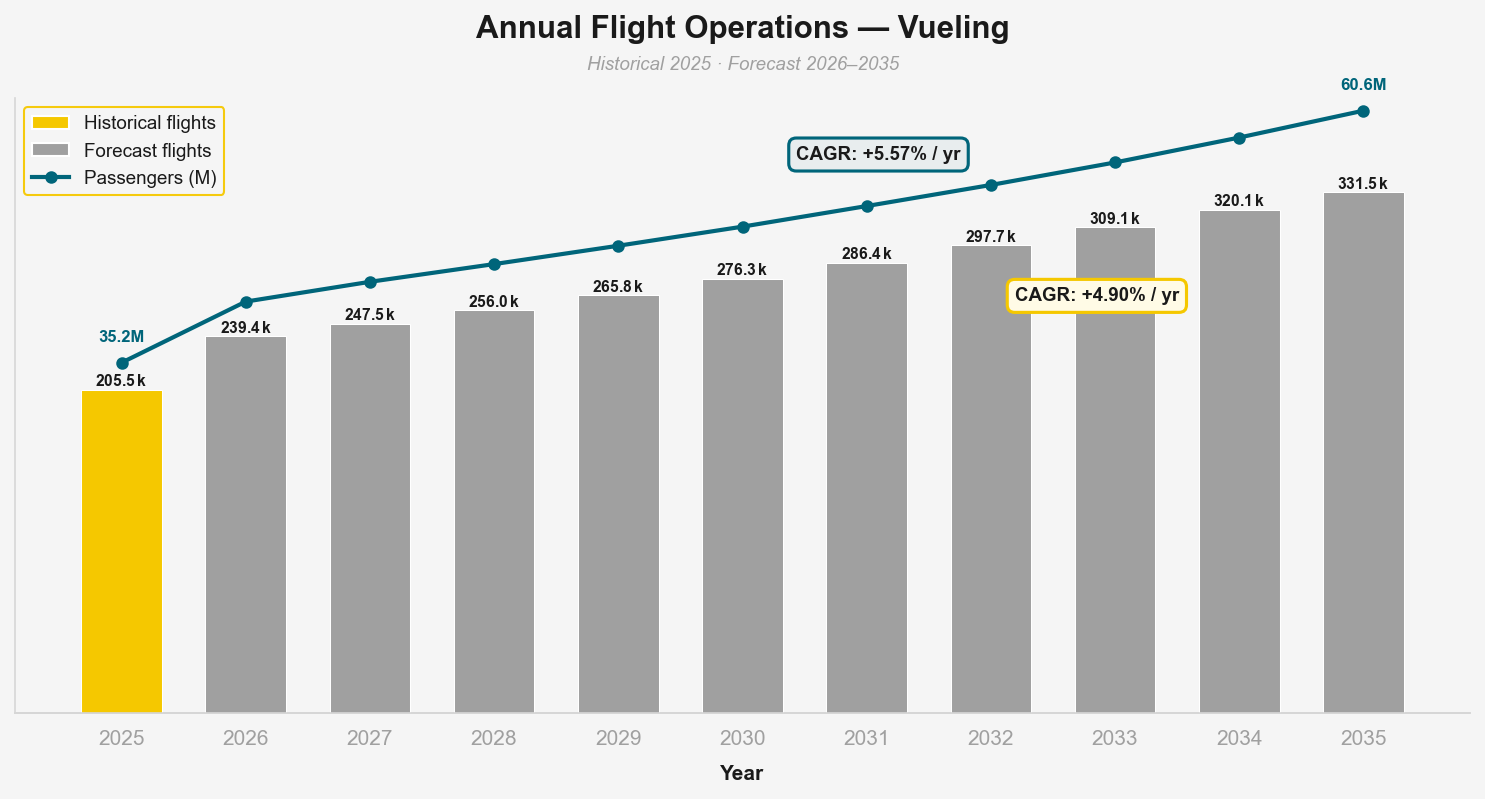

In [4]:
# ── A1. ANNUAL FLIGHTS ────────────────────────────────────────────────────────
annual = df.groupby(['year','is_forecast']).agg(
    flights=('flights_count','sum'),
    co2=('Total_CO2_sum','sum'),
    pax=('pax','sum')
).reset_index()

years      = annual['year'].values
flights    = annual['flights'].values
pax_values = annual['pax'].values
is_fc      = annual['is_forecast'].values
colors_a   = [VY['yellow'] if not f else VY['grey'] for f in is_fc]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.set_axisbelow(True)
ax.grid(True, axis='y', color='#E0E0E0', linewidth=0.6, zorder=0)
ax.grid(False, axis='x')

bars = ax.bar(years, flights/1e3, color=colors_a, width=0.65,
              edgecolor='white', linewidth=0.5, zorder=3)

for bar, val in zip(bars, flights):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            rf'{val/1e3:,.1f}$\,$k',
            ha='center', va='bottom', fontsize=7.5,
            color=VY['dark'], fontweight='bold')

# CAGR
cagr_flights = (flights[-1] / flights[0]) ** (1/10) - 1
ax.annotate(f"CAGR: {cagr_flights:+.2%} / yr",
            xy=(0.8, 0.67), xycoords='axes fraction',
            ha='right', fontsize=9, color=VY['dark'], fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFFBE6',
                      edgecolor=VY['yellow'], lw=1.5))
cagr_pax = (pax_values[-1] / pax_values[0]) ** (1/10) - 1
ax.annotate(f"CAGR: {cagr_pax:+.2%} / yr",
            xy=(0.65, 0.9), xycoords='axes fraction',
            ha='right', fontsize=9, color=VY['dark'], fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=(*mcolors.to_rgb(IC['deep_teal']), 0.05),
                      edgecolor=VY['deep_teal'], lw=1.5))


ax.set_ylim(0, max(flights/1e3) * 1.18)
ax.yaxis.set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color(VY['light_grey'])
ax.set_xlabel('Year', labelpad=8)
ax.set_xticks(years)
ax.tick_params(axis='x', length=0, pad=8)

# ── Pax line (right axis) ─────────────────────────────────────────────────────
ax2 = ax.twinx()
ax2.plot(years, pax_values / 1e6,
         color=VY['deep_teal'], lw=2, marker='o', ms=5, zorder=4)
# ax2.fill_between(years, pax_values / 1e6,
#                  color=VY['deep_teal'], alpha=0.06, zorder=1)

# Endpoint annotations
for idx in [0, len(years)-1]:
    ax2.annotate(f"{pax_values[idx]/1e6:.1f}M",
                 xy=(years[idx], pax_values[idx]/1e6),
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=8, color=VY['deep_teal'], fontweight='bold')

ax2.yaxis.set_visible(False)
# ax2.set_ylabel('Passengers (M)', fontsize=9, color=VY['deep_teal'])
# # ax2.tick_params(axis='y', colors=VY['deep_teal'])
# ax2.spines['right'].set_color(VY['deep_teal'])
# ax2.spines['left'].set_visible(False)
# ax2.spines['bottom'].set_color(VY['light_grey'])
# ax2.spines['top'].set_visible(False)
ax2.set_ylim(bottom=0)
ax2.yaxis.grid(False)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=VY['yellow'],     label='Historical flights', ec='white'),
    mpatches.Patch(color=VY['grey'],       label='Forecast flights',   ec='white'),
    Line2D([0], [0], color=VY['deep_teal'], lw=2, marker='o', ms=5,
           label='Passengers (M)'),
]
leg = ax.legend(handles=legend_patches, loc='upper left', fontsize=9)
style_legend(leg, edge_color=VY['yellow'])

styled_title(fig, 'Annual Flight Operations — Vueling',
             'Historical 2025 · Forecast 2026–2035')

fig.tight_layout(rect=[0, 0.02, 1, 0.93])
fig.savefig('../0. Data/Figures/A1_annual_flights_pax_202_fleet.pdf', bbox_inches='tight')
plt.show()

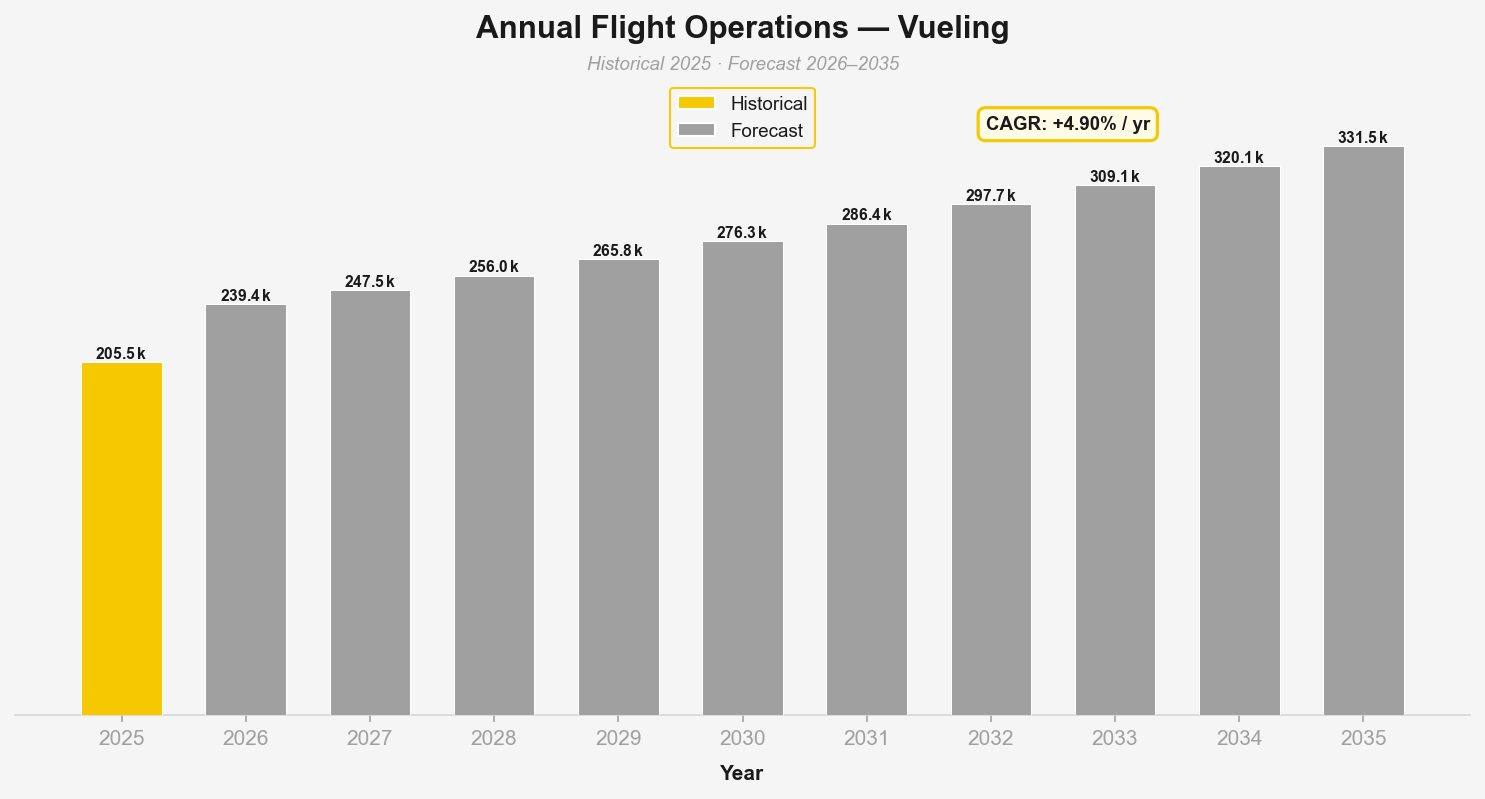

In [5]:
# ── A1. ANNUAL FLIGHTS ────────────────────────────────────────────────────────
annual = df.groupby(['year','is_forecast']).agg(
    flights=('flights_count','sum'),
    co2=('Total_CO2_sum','sum')
).reset_index()

years   = annual['year'].values
flights = annual['flights'].values
is_fc   = annual['is_forecast'].values
colors_a = [VY['yellow'] if not f else VY['grey'] for f in is_fc]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.set_axisbelow(True)
ax.grid(True, axis='y', color='#E0E0E0', linewidth=0.6, zorder=0)
ax.grid(False, axis='x')

bars = ax.bar(years, flights/1e3, color=colors_a, width=0.65,
              edgecolor='white', linewidth=0.5, zorder=3)

for bar, val in zip(bars, flights):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            rf'{val/1e3:,.1f}$\,$k',
            ha='center', va='bottom', fontsize=7.5,
            color=VY['dark'], fontweight='bold')

# CAGR
cagr_flights = (flights[-1] / flights[0]) ** (1/10) - 1
ax.annotate(f"CAGR: {cagr_flights:+.2%} / yr",
            xy=(0.78, 0.92), xycoords='axes fraction',
            ha='right', fontsize=9, color=VY['dark'], fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFFBE6',
                      edgecolor=VY['yellow'], lw=1.5))

ax.set_ylim(0, max(flights/1e3) * 1.12)
ax.yaxis.set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color(VY['light_grey'])
ax.set_xlabel('Year', labelpad=8)
ax.set_xticks(years)

legend_patches = [
    mpatches.Patch(color=VY['yellow'], label='Historical', ec='white'),
    mpatches.Patch(color=VY['grey'],   label='Forecast',   ec='white'),
]
leg = ax.legend(handles=legend_patches, loc='upper center', fontsize=9)
style_legend(leg, edge_color=VY['yellow'])

styled_title(fig, 'Annual Flight Operations — Vueling',
             'Historical 2025 · Forecast 2026–2035')
fig.tight_layout(rect=[0,0.02,1,0.93])
fig.savefig('../0. Data/Figures/A1_annual_flights_202_fleet.pdf', bbox_inches='tight')
plt.show()

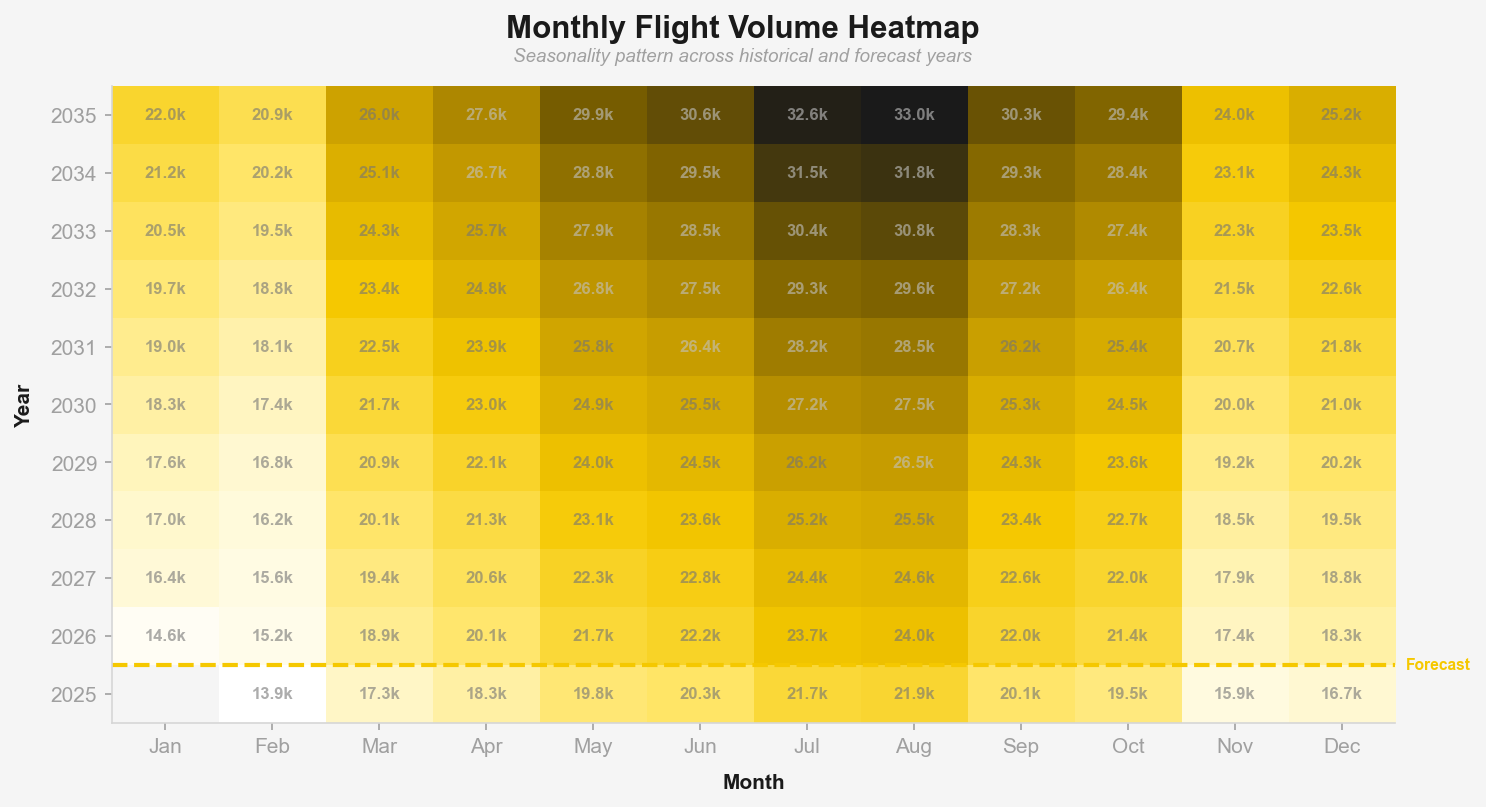

In [6]:
# ── A2. MONTHLY FLIGHT HEATMAP ────────────────────────────────────────────────
pivot_flights = df.groupby(['year','month'])['flights_count'].sum().unstack('month')

MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 5.5))
im = ax.imshow(pivot_flights.values, aspect='auto',
               cmap=IC_CMAP, interpolation='nearest')

ax.set_xticks(range(12))
ax.set_xticklabels(MONTH_LABELS)
ax.set_yticks(range(len(pivot_flights.index)))
ax.set_yticklabels(pivot_flights.index)
ax.grid(False)
ax.invert_yaxis()

vmax = np.nanmax(pivot_flights.values)
for i, year in enumerate(pivot_flights.index):
    for j, month in enumerate(pivot_flights.columns):
        val = pivot_flights.loc[year, month]
        if not np.isnan(val):
            brightness = val / vmax  # 0.0 (low) → 1.0 (high/dark cell)
            # low values → dark text on light cell; high values → light text on dark cell
            if brightness < 0.55:
                txt_color = "#757575"   # dark grey on light/yellow cells
            elif brightness < 0.8:
                txt_color = "#747474"   # near-black on mid cells
            else:
                txt_color = "#C2C2C2"   # near-white on dark cells
            ax.text(j, i, f'{val/1e3:.1f}k', ha='center', va='center',
                    fontsize=8, color=txt_color, fontweight='bold', alpha=0.6)

hist_rows = sum(1 for y in pivot_flights.index if y <= 2025)
ax.axhline(hist_rows - 0.5, color=VY['yellow'], lw=2, ls='--')
ax.text(11.6, hist_rows - 0.5, 'Forecast', color=VY['yellow'],
        fontsize=7.5, va='center', ha='left', fontweight='bold')

ax.set_xlabel('Month')
ax.set_ylabel('Year')
styled_title(fig, 'Monthly Flight Volume Heatmap',
             'Seasonality pattern across historical and forecast years', y_pad=0.04)
fig.tight_layout(rect=[0,0.01,1,0.92])
fig.savefig('../0. Data/Figures/A2_monthly_heatmap_202_fleet.pdf', bbox_inches='tight')
plt.show()

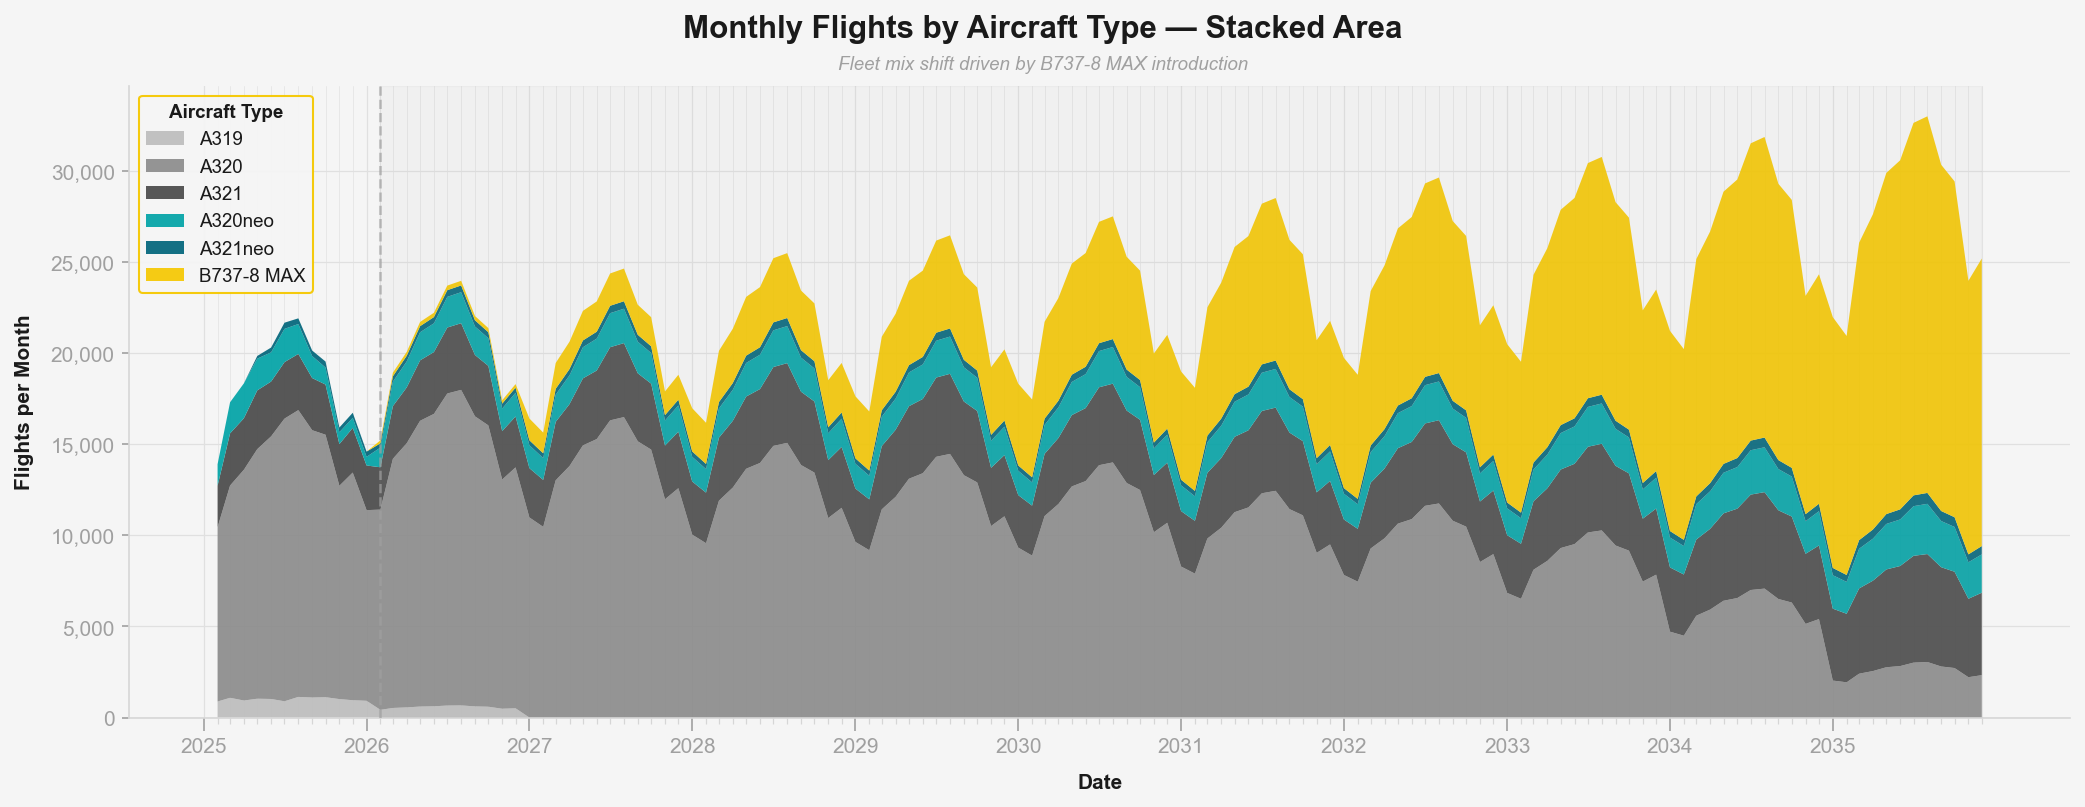

In [7]:
# ── A3. FLIGHTS BY AIRCRAFT TYPE — STACKED AREA ──────────────────────────────
ym_type = df.groupby(['year_month','aircraft_type_icao'])['flights_count'].sum().unstack(fill_value=0)
ym_type.index = pd.to_datetime(ym_type.index + '-01')

type_order = [t for t in ['A319','A320','A321','A320Neo','A321Neo','B38M']
              if t in ym_type.columns]
ym_type = ym_type[type_order]

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.set_axisbelow(True)
ax.grid(True, color='#E0E0E0', linewidth=0.6, zorder=0)

ax.stackplot(ym_type.index,
             [ym_type[t] for t in type_order],
             labels=[AC_LABELS.get(t, t) for t in type_order],
             colors=[AC_COLORS_A3.get(t, VY['grey']) for t in type_order],
             alpha=0.92, zorder=2)

fc_start = pd.Timestamp('2026-02-01')
ax.axvspan(fc_start, ym_type.index[-1], **{**FORECAST_SHADE, 'zorder': 3})
ax.axvline(fc_start, color=VY['grey'], lw=1.2, ls='--', alpha=0.7, zorder=4)

ax.set_xlabel('Date')
ax.set_ylabel('Flights per Month')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))


# ax.set_xticks([pd.Timestamp(f'{y}-01-01') for y in range(2025, 2036)])
# ax.set_xticklabels([f'{y}' for y in range(2025, 2036)])



# Monthly ticks (minor) + yearly labels (major)
ax.set_xticks([pd.Timestamp(f'{y}-{m:02d}-01')
               for y in range(2025, 2036)
               for m in range(1, 13)], minor=True)
ax.set_xticks([pd.Timestamp(f'{y}-01-01') for y in range(2025, 2036)])
ax.set_xticklabels([f'{y}' for y in range(2025, 2036)])
ax.tick_params(axis='x', which='minor', length=3, color=VY['light_grey'])
ax.tick_params(axis='x', which='major', length=6, color=VY['grey'])
ax.grid(True, axis='x', which='minor', color='#E0E0E0', linewidth=0.3, zorder=0)




ax.spines['left'].set_color(VY['light_grey'])
ax.spines['bottom'].set_color(VY['light_grey'])

leg = ax.legend(loc='upper left', fontsize=9, title='Aircraft Type', title_fontsize=9)
style_legend(leg)

styled_title(fig, 'Monthly Flights by Aircraft Type — Stacked Area',
             'Fleet mix shift driven by B737-8 MAX introduction')
fig.tight_layout(rect=[0,0.01,1,0.92])
fig.savefig('../0. Data/Figures/A3_flights_stacked_area_202_fleet.pdf', bbox_inches='tight')
plt.show()

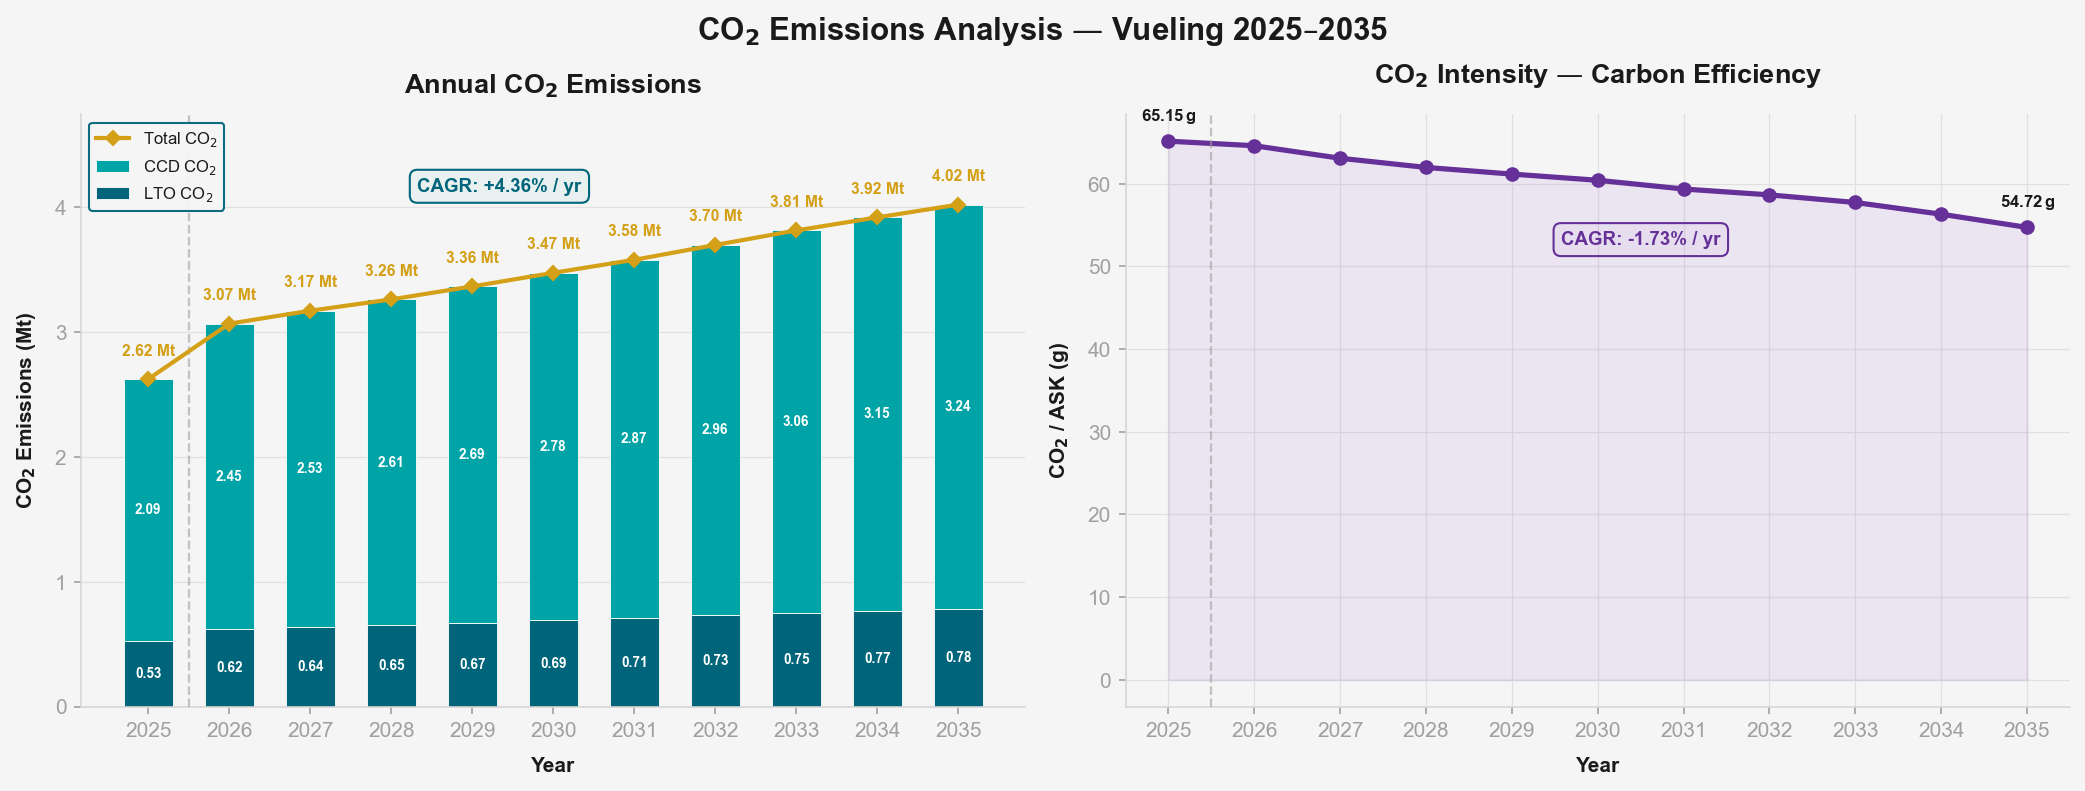

In [8]:
# ── A4. CO2 EMISSIONS TRAJECTORY ─────────────────────────────────────────────
SEATS = {
    'A319': 144, 'A320': 186, 'A321': 228,
    'A320Neo': 186, 'A321Neo': 236, 'B38M': 200
}

seats_by_year = (
    df.groupby(['year','aircraft_type_icao'])
    .agg(flights=('flights_count','sum')).reset_index()
    .assign(seats=lambda x: x['aircraft_type_icao'].map(SEATS).fillna(180))
    .assign(seat_flights=lambda x: x['flights'] * x['seats'])
    .groupby('year')
    .apply(lambda g: g['seat_flights'].sum() / g['flights'].sum())
    .rename('avg_seats')
)

annual_co2 = df.groupby('year').agg(
    total_flights         = ('flights_count',         'sum'),
    total_co2             = ('Total_CO2_sum',          'sum'),
    lto_co2               = ('LTO_CO2_sum',            'sum'),
    ccd_co2               = ('CCD_CO2_sum',            'sum'),
    total_distance_km_sum = ('total_distance_km_sum',  'sum'),
).reset_index()

annual_co2 = annual_co2.join(seats_by_year, on='year')
annual_co2['total_ask']   = annual_co2['total_distance_km_sum'] * annual_co2['avg_seats']
annual_co2['co2_per_ask'] = annual_co2['total_co2'] / annual_co2['total_ask']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# — Left: stacked bars ─────────────────────────────────────────────────────────
ax1.set_axisbelow(True)
ax1.grid(True, axis='y', color='#E0E0E0', linewidth=0.6, zorder=0)
ax1.grid(False, axis='x')

ax1.bar(annual_co2['year'], annual_co2['lto_co2']/1e9, width=0.6,
        color=VY['deep_teal'], label=r'LTO CO$_2$', edgecolor='white', lw=0.4, zorder=2)
ax1.bar(annual_co2['year'], annual_co2['ccd_co2']/1e9, width=0.6,
        bottom=annual_co2['lto_co2']/1e9,
        color=VY['teal'],      label=r'CCD CO$_2$', edgecolor='white', lw=0.4, zorder=2)

ax1.plot(annual_co2['year'], annual_co2['total_co2']/1e9,
         color=VY['gold'], lw=2, marker='D', ms=4.5, zorder=5, label=r'Total CO$_2$')

for _, row in annual_co2.iterrows():
    lto   = row['lto_co2']  / 1e9
    ccd   = row['ccd_co2']  / 1e9
    total = row['total_co2']/ 1e9
    ax1.text(row['year'], lto / 2, f"{lto:.2f}",
             ha='center', va='center', fontsize=6.5, color='white', fontweight='bold', zorder=6)
    ax1.text(row['year'], lto + ccd / 2, f"{ccd:.2f}",
             ha='center', va='center', fontsize=6.5, color='white', fontweight='bold', zorder=6)
    ax1.annotate(f"{total:.2f} Mt",
                 xy=(row['year'], total), xytext=(0, 10), textcoords='offset points',
                 ha='center', va='bottom', fontsize=7.5, color=VY['gold'], fontweight='bold')

ax1.set_ylim(0, annual_co2['total_co2'].max()/1e9 * 1.18)
ax1.axvline(2025.5, color=VY['grey'], lw=1.1, ls='--', alpha=0.6, zorder=4)
ax1.set_xlabel('Year')
ax1.set_ylabel(r'CO$\mathbf{_2}$ Emissions (Mt)', labelpad=8)
ax1.set_title(r'Annual CO$\mathbf{_2}$ Emissions', pad=10)
ax1.set_xticks(annual_co2['year'])
ax1.spines['left'].set_color(VY['light_grey'])
ax1.spines['bottom'].set_color(VY['light_grey'])

handles, labels = ax1.get_legend_handles_labels()
order = [0, 2, 1]
leg = ax1.legend([handles[i] for i in order], [labels[i] for i in order],
                 fontsize=8, loc='upper left')
style_legend(leg, edge_color=VY['deep_teal'])

cagr_total = (annual_co2['total_co2'].iloc[-1] / annual_co2['total_co2'].iloc[0]) ** (1/10) - 1
ax1.annotate(f"CAGR: {cagr_total:+.2%} / yr",
             xy=(0.53, 0.87), xycoords='axes fraction',
             ha='right', fontsize=9, color=VY['deep_teal'], fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.4', facecolor=(*mcolors.to_rgb(IC['teal']), 0.05),
                       edgecolor=VY['deep_teal'], lw=1))

# — Right: CO2/ASK ─────────────────────────────────────────────────────────────
ax2.set_axisbelow(True)
ax2.grid(True, color='#E0E0E0', linewidth=0.6, zorder=0)

ax2.plot(annual_co2['year'], annual_co2['co2_per_ask'],
         color=IC['violet'], lw=2.5, marker='o', ms=6, zorder=4)
ax2.fill_between(annual_co2['year'], annual_co2['co2_per_ask'],
                 alpha=0.10, color=IC['lavender'], zorder=3)
ax2.axvline(2025.5, color=VY['grey'], lw=1.1, ls='--', alpha=0.6, zorder=4)

for _, row in annual_co2.iloc[[0, -1]].iterrows():
    ax2.annotate(rf"{row['co2_per_ask']*1000:.2f}$\,$g",
                 xy=(row['year'], row['co2_per_ask']),
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=8, color=VY['dark'], fontweight='bold')

cagr_ask = (annual_co2['co2_per_ask'].iloc[-1] / annual_co2['co2_per_ask'].iloc[0]) ** (1/10) - 1

ax2.annotate(f"CAGR: {cagr_ask:+.2%} / yr",
             xy=(0.63, 0.78), xycoords='axes fraction',
             ha='right', fontsize=9, color=IC['violet'], fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.4',
                       facecolor=(*mcolors.to_rgb(IC['lavender']), 0.05),
                       edgecolor=IC['violet'], lw=1))

ax2.set_xlabel('Year', labelpad=8)
ax2.set_ylabel(r'CO$\mathbf{_2}$ / ASK (g)', labelpad=8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x*1000:.0f}'))
ax2.set_title(r'CO$\mathbf{_2}$ Intensity — Carbon Efficiency', pad=15)
ax2.set_xticks(annual_co2['year'])
ax2.spines['left'].set_color(VY['light_grey'])
ax2.spines['bottom'].set_color(VY['light_grey'])

styled_title(fig, r'CO$\mathbf{_2}$ Emissions Analysis — Vueling 2025–2035')
fig.tight_layout(rect=[0,0.01,1,0.93])
fig.savefig('../0. Data/Figures/A4_co2_analysis_202_fleet.pdf', bbox_inches='tight')
plt.show()

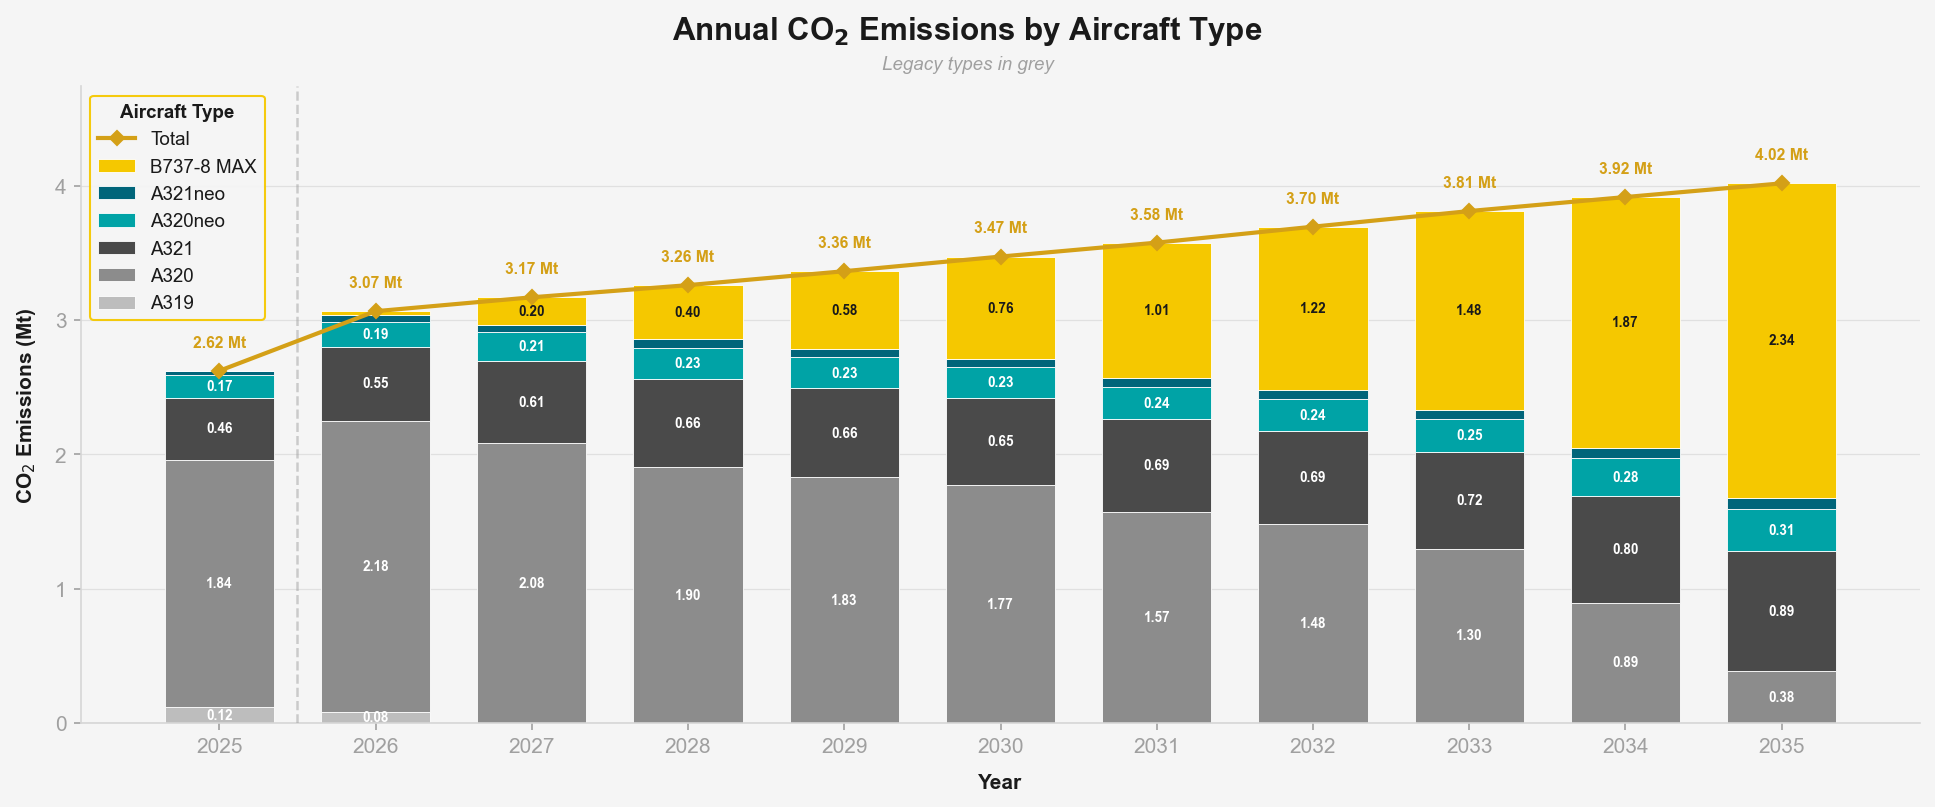

In [9]:
# ── A5. CO2 BY AIRCRAFT TYPE — ANNUAL STACKED BAR ────────────────────────────
co2_type = df.groupby(['year','aircraft_type_icao'])['Total_CO2_sum'].sum().unstack(fill_value=0)
type_order_a5 = [t for t in ['A319','A320','A321','A320Neo','A321Neo','B38M']
                 if t in co2_type.columns]
co2_type = co2_type[type_order_a5]

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.set_axisbelow(True)
ax.grid(True, axis='y', color='#E0E0E0', linewidth=0.6, zorder=0)
ax.grid(False, axis='x')

bottom   = np.zeros(len(co2_type))
occupied = {yr: [] for yr in co2_type.index}

for ac in co2_type.columns:
    vals = co2_type[ac].values / 1e9
    ax.bar(co2_type.index, vals, bottom=bottom, width=0.7,
           color=AC_COLORS_A3.get(ac, VY['grey']), label=AC_LABELS.get(ac, ac),
           edgecolor='white', linewidth=0.4, zorder=2)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v < 0.05:
            continue
        yr    = co2_type.index[i]
        y_mid = b + v / 2
        txt_half = 0.1
        overlaps = any(
            (y_mid - txt_half) < y_high and (y_mid + txt_half) > y_low
            for (y_low, y_high) in occupied[yr]
        )
        if not overlaps:
            # use dark text on yellow (B38M), white on dark segments
            txt_c = VY['dark'] if AC_COLORS_A3.get(ac) == VY['yellow'] else 'white'
            ax.text(yr, y_mid, f"{v:.2f}",
                    ha='center', va='center', fontsize=6.5,
                    color=txt_c, fontweight='bold', zorder=6)
            occupied[yr].append((y_mid - txt_half, y_mid + txt_half))
    bottom += vals

totals_co2 = co2_type.sum(axis=1) / 1e9
ax.plot(co2_type.index, totals_co2, color=VY['gold'], lw=2,
        marker='D', ms=5, zorder=5, label='Total')

for year, val in totals_co2.items():
    ax.annotate(f"{val:.2f} Mt",
                xy=(year, val), xytext=(0, 10), textcoords='offset points',
                ha='center', va='bottom', fontsize=7.5,
                color=VY['gold'], fontweight='bold')

ax.set_ylim(0, totals_co2.max() * 1.18)
ax.axvline(2025.5, color=VY['grey'], lw=1.2, ls='--', alpha=0.5, zorder=3)
ax.set_xlabel('Year')
ax.set_ylabel(r'CO$_2$ Emissions (Mt)', labelpad=8)
ax.set_xticks(co2_type.index)
ax.spines['left'].set_color(VY['light_grey'])
ax.spines['bottom'].set_color(VY['light_grey'])

handles, labels = ax.get_legend_handles_labels()
order = [0, 6, 5, 4, 3, 2, 1]
leg = ax.legend([handles[i] for i in order], [labels[i] for i in order],
                title='Aircraft Type', fontsize=9, title_fontsize=9)
style_legend(leg)

styled_title(fig, r'Annual CO$\mathbf{_2}$ Emissions by Aircraft Type',
             r'Legacy types in grey')
fig.tight_layout(rect=[0,0.01,1,0.92])
fig.savefig('../0. Data/Figures/A5_co2_by_type_202_fleet.pdf', bbox_inches='tight')
plt.show()

---
## Section B — Vehicle Fleet & Projections

Using fleet_evolution ✓


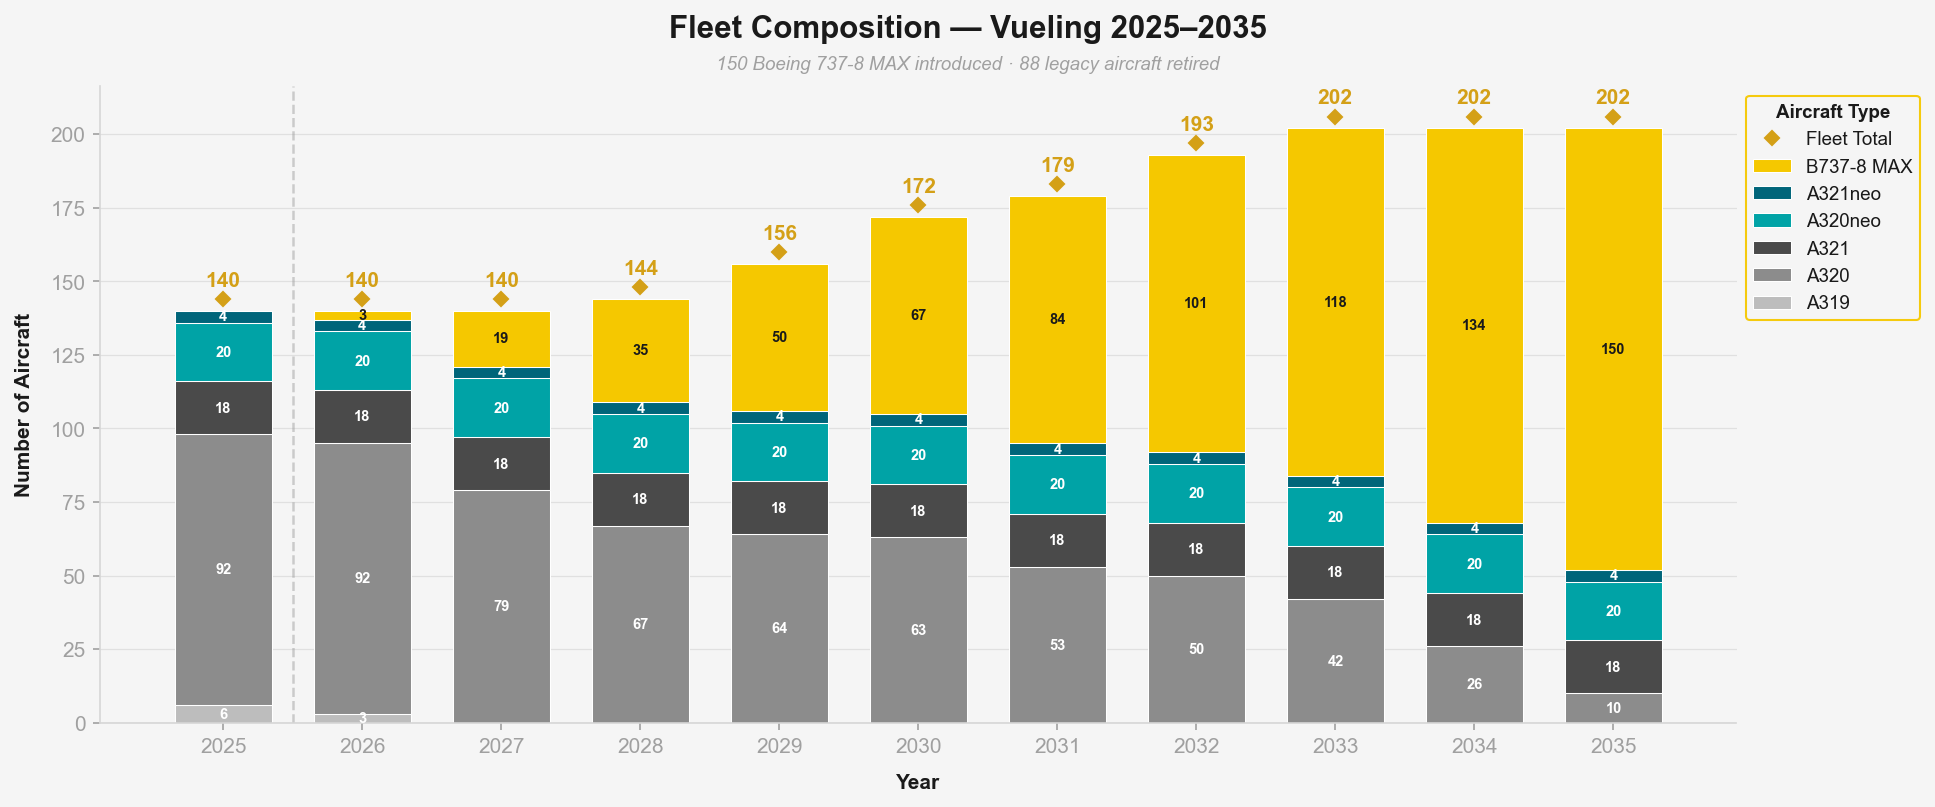

In [10]:
# ── B1. FLEET COMPOSITION — STACKED BAR OVER TIME ────────────────────────────
fleet_evolution = pd.read_csv('../0. Data/fleet_evolution.csv', index_col=0)
fleet_evolution.index = fleet_evolution.index.astype(int)

try:
    fleet_evo = fleet_evolution.drop(columns='TOTAL', errors='ignore').copy()
    fleet_evo = fleet_evo.sort_index()
    print('Using fleet_evolution ✓')
except NameError:
    print('fleet_evolution not found')

type_order_fleet = [t for t in ['A319','A320','A321','A320Neo','A321Neo','B38M']
                    if t in fleet_evo.columns]

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.set_axisbelow(True)
ax.grid(True, axis='y', color='#E0E0E0', linewidth=0.6, zorder=0)
ax.grid(False, axis='x')

bottom = np.zeros(len(fleet_evo))
for ac in type_order_fleet:
    if ac not in fleet_evo.columns:
        continue
    vals = fleet_evo[ac].fillna(0).values
    ax.bar(fleet_evo.index, vals, bottom=bottom, width=0.7,
           color=AC_COLORS_A3.get(ac, VY['grey']), label=AC_LABELS.get(ac, ac),
           edgecolor='white', linewidth=0.5, zorder=2)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v >= 3:
            txt_c = VY['dark'] if AC_COLORS_A3.get(ac) == VY['yellow'] else 'white'
            ax.text(fleet_evo.index[i], b + v/2, str(int(v)),
                    ha='center', va='center', fontsize=7,
                    color=txt_c, fontweight='bold')
    bottom += vals

totals = fleet_evo[type_order_fleet].sum(axis=1)
ax.plot(fleet_evo.index, totals + 4, color=VY['gold'], lw=0,
        marker='D', ms=5, zorder=5, label='Fleet Total')
for i, total in enumerate(totals):
    ax.text(fleet_evo.index[i], total + 7, str(int(total)),
            ha='center', va='bottom', fontsize=10,
            color=VY['gold'], fontweight='bold')
    
ax.axvline(2025.5, color=VY['grey'], lw=1.2, ls='--', alpha=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Aircraft')
ax.set_xticks(fleet_evo.index)
ax.spines['left'].set_color(VY['light_grey'])
ax.spines['bottom'].set_color(VY['light_grey'])

handles, labels = ax.get_legend_handles_labels()
order = [0, 6, 5, 4, 3, 2, 1]
leg = ax.legend([handles[i] for i in order], [labels[i] for i in order],
                title='Aircraft Type', fontsize=9, title_fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))

style_legend(leg)

styled_title(fig, 'Fleet Composition — Vueling 2025–2035',
             '150 Boeing 737-8 MAX introduced · 88 legacy aircraft retired')
fig.tight_layout(rect=[0,0.01,1,0.92])
fig.savefig('../0. Data/Figures/B1_fleet_stacked_bar_202_fleet.pdf', bbox_inches='tight')
plt.show()

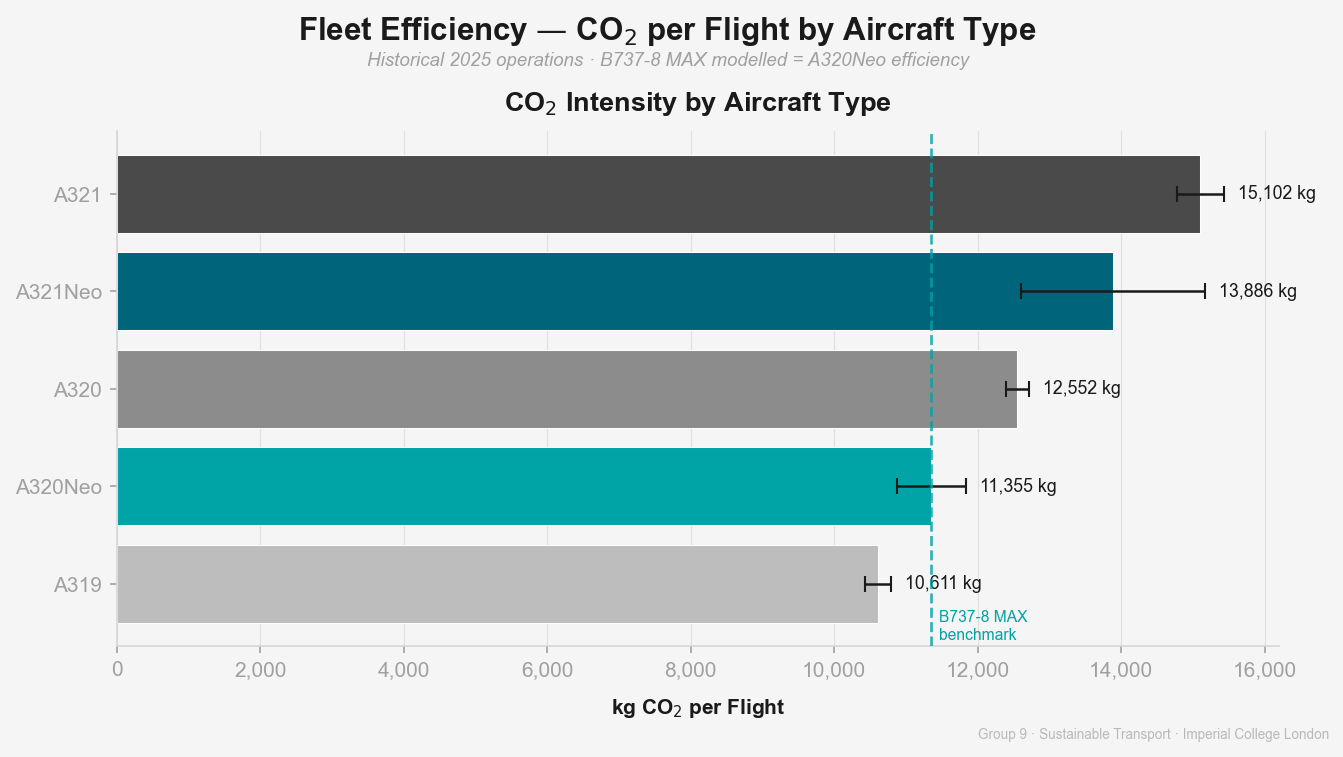

In [11]:
# ── B5. CO2 INTENSITY BY AIRCRAFT TYPE ───────────────────────────────────────
hist_df = df[~df['is_forecast']].copy()
hist_df['co2_per_flight'] = hist_df['Total_CO2_sum'] / hist_df['flights_count']

type_stats = hist_df.groupby('aircraft_type_icao')['co2_per_flight'].agg(['mean','std']).reset_index()
type_stats = type_stats.sort_values('mean')

fig, ax = plt.subplots(figsize=(9, 5))
ax.set_axisbelow(True)
ax.grid(True, axis='x', color='#E0E0E0', linewidth=0.6, zorder=0)
ax.grid(False, axis='y')

colors_b = [AC_COLORS_A3.get(t, VY['grey']) for t in type_stats['aircraft_type_icao']]
bars = ax.barh(type_stats['aircraft_type_icao'], type_stats['mean'],
               xerr=type_stats['std'], color=colors_b,
               edgecolor='white', lw=0.5,
               error_kw=dict(elinewidth=1.2, ecolor=VY['dark'], capsize=4), zorder=2)

for i, row in type_stats.iterrows():
    ax.text(row['mean'] + row['std'] + 200, type_stats.index.get_loc(i),
            f"{row['mean']:,.0f} kg", va='center', fontsize=8.5, color=VY['dark'])

neo_val = type_stats[type_stats['aircraft_type_icao']=='A320Neo']['mean'].values
if len(neo_val):
    ax.axvline(neo_val[0], color=VY['teal'], lw=1.3, ls='--', alpha=0.8, zorder=4)
    ax.text(neo_val[0]+100, -0.6, 'B737-8 MAX\nbenchmark',
            color=VY['teal'], fontsize=7.5, va='bottom')

ax.set_xlabel(r'kg CO$_2$ per Flight')
ax.set_title(r'CO$_2$ Intensity by Aircraft Type', pad=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.spines['left'].set_color(VY['light_grey'])
ax.spines['bottom'].set_color(VY['light_grey'])

styled_title(fig, r'Fleet Efficiency — CO$_2$ per Flight by Aircraft Type',
             'Historical 2025 operations · B737-8 MAX modelled = A320Neo efficiency')
watermark(fig)
fig.tight_layout(rect=[0,0.01,1,0.91])
fig.savefig('../0. Data/Figures/B5_co2_intensity.pdf', bbox_inches='tight')
plt.show()

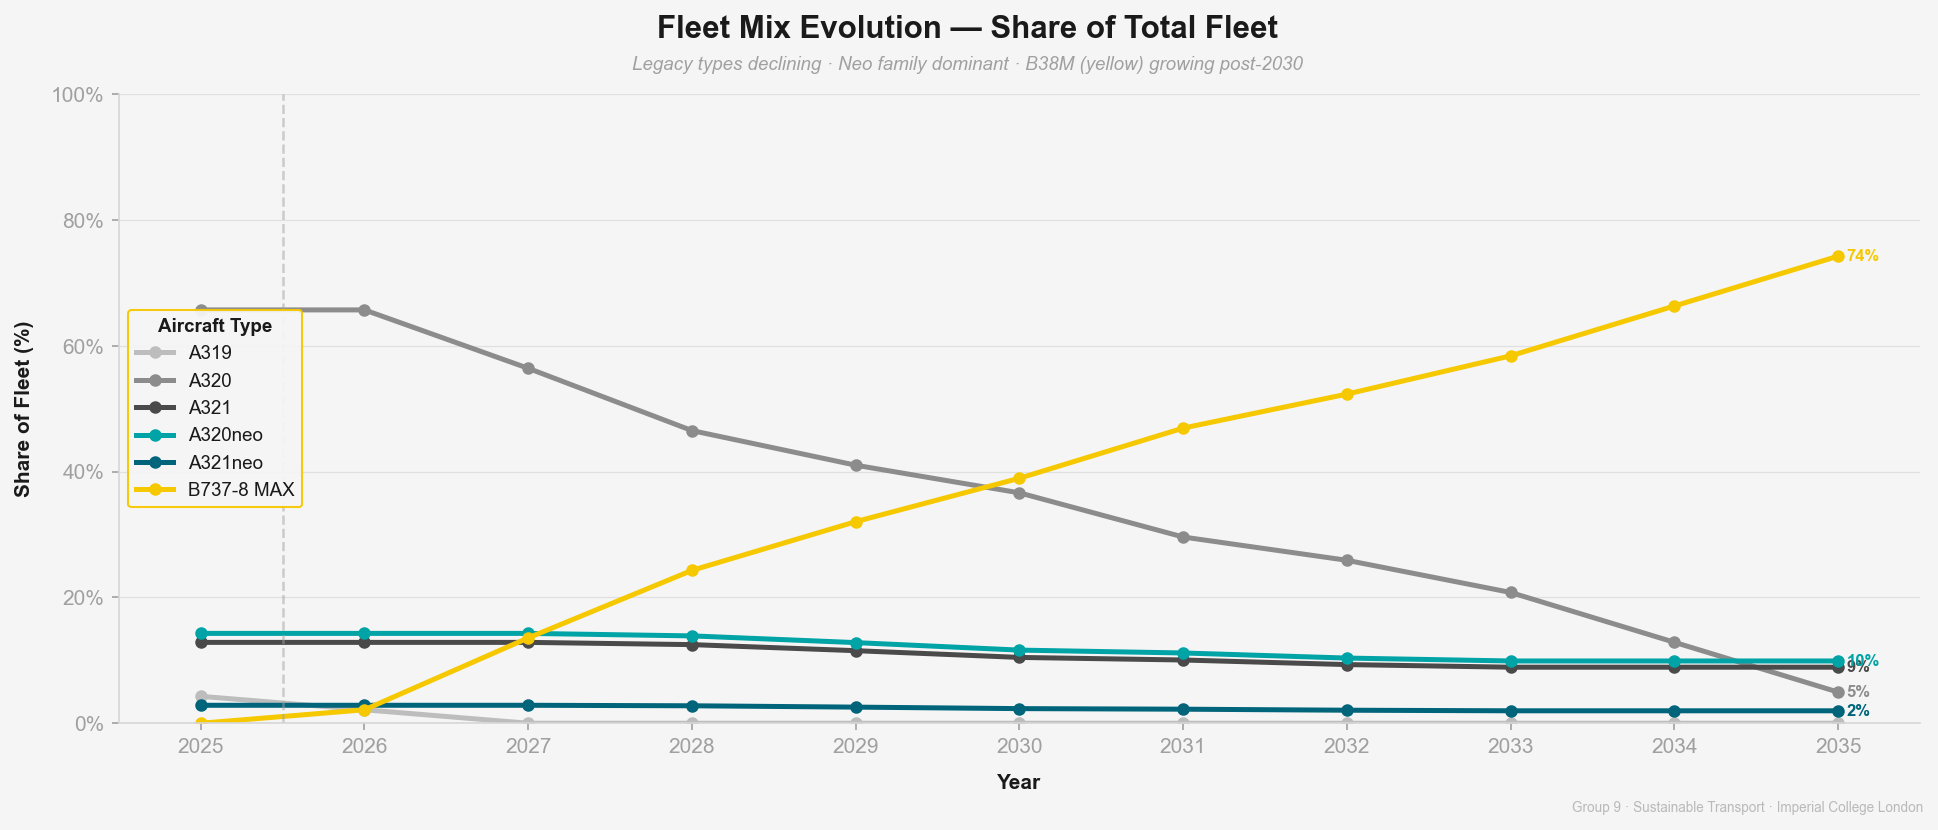

In [12]:
# ── B6. FLEET MIX SHARE — LINE CHART ─────────────────────────────────────────
fleet_pct = fleet_evo[type_order_fleet].div(fleet_evo[type_order_fleet].sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.set_axisbelow(True)
ax.grid(True, axis='y', color='#E0E0E0', linewidth=0.6, zorder=0)
ax.grid(False, axis='x')

for ac in type_order_fleet:
    if ac not in fleet_pct.columns:
        continue
    vals = fleet_pct[ac].fillna(0)
    ax.plot(fleet_pct.index, vals, color=AC_COLORS_A3.get(ac, VY['grey']),
            lw=2.4, marker='o', ms=5, label=AC_LABELS.get(ac, ac))
    last_val = vals.iloc[-1]
    if last_val > 1:
        ax.annotate(f'{last_val:.0f}%', xy=(fleet_pct.index[-1], last_val),
                    xytext=(4, 0), textcoords='offset points',
                    fontsize=8, color=AC_COLORS_A3.get(ac, VY['grey']),
                    fontweight='bold', va='center')

ax.axvline(2025.5, color=VY['grey'], lw=1.2, ls='--', alpha=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('Share of Fleet (%)')
ax.set_xticks(fleet_evo.index)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
ax.spines['left'].set_color(VY['light_grey'])
ax.spines['bottom'].set_color(VY['light_grey'])

leg = ax.legend(title='Aircraft Type', fontsize=9, title_fontsize=9, loc='center left')
style_legend(leg)

styled_title(fig, 'Fleet Mix Evolution — Share of Total Fleet',
             'Legacy types declining · Neo family dominant · B38M (yellow) growing post-2030')
watermark(fig)
fig.tight_layout(rect=[0,0.01,1,0.92])
fig.savefig('../0. Data/Figures/B6_fleet_mix_share_202_fleet.pdf', bbox_inches='tight')
plt.show()

In [13]:
# ── SUMMARY: ALL SAVED FILES ──────────────────────────────────────────────────
import os
plots = [
    ('A1_annual_flights.png',     'A1 · Annual flight operations'),
    ('A2_monthly_heatmap.png',    'A2 · Monthly flight volume heatmap'),
    ('A3_flights_stacked_area.png','A3 · Flights by aircraft type (stacked area)'),
    ('A4_co2_analysis.png',       'A4 · CO₂ emissions analysis'),
    ('A5_co2_by_type.png',        'A5 · Annual CO₂ by aircraft type'),
    ('A6_seasonal_polar.png',     'A6 · Seasonal profile (polar)'),
    ('B1_fleet_stacked_bar.png',  'B1 · Fleet composition (stacked bar)'),
    ('B2_fleet_pie.png',          'B2 · Fleet snapshots (pie charts)'),
    ('B3_sankey.png',             'B3 · Fleet transition Sankey 2025→2035'),
    ('B4_delivery_retirement.png','B4 · Delivery & retirement schedule'),
    ('B5_co2_intensity.png',      'B5 · CO₂ intensity by aircraft type'),
    ('B6_fleet_mix_share.png',    'B6 · Fleet mix share evolution'),
]
print('Generated plots:')
for fname, desc in plots:
    exists = '✓' if os.path.exists(fname) else '✗ (not yet generated)'
    print(f'  {exists}  {desc:50s}  [{fname}]')

Generated plots:
  ✗ (not yet generated)  A1 · Annual flight operations                       [A1_annual_flights.png]
  ✗ (not yet generated)  A2 · Monthly flight volume heatmap                  [A2_monthly_heatmap.png]
  ✗ (not yet generated)  A3 · Flights by aircraft type (stacked area)        [A3_flights_stacked_area.png]
  ✗ (not yet generated)  A4 · CO₂ emissions analysis                         [A4_co2_analysis.png]
  ✗ (not yet generated)  A5 · Annual CO₂ by aircraft type                    [A5_co2_by_type.png]
  ✗ (not yet generated)  A6 · Seasonal profile (polar)                       [A6_seasonal_polar.png]
  ✗ (not yet generated)  B1 · Fleet composition (stacked bar)                [B1_fleet_stacked_bar.png]
  ✗ (not yet generated)  B2 · Fleet snapshots (pie charts)                   [B2_fleet_pie.png]
  ✗ (not yet generated)  B3 · Fleet transition Sankey 2025→2035              [B3_sankey.png]
  ✗ (not yet generated)  B4 · Delivery & retirement schedule                 [B4_d

---

In [14]:
import pandas as pd
import re

raw = """Airbus A320-271N 8181 7 years
Airbus A320-271N 8467 7 years
Airbus A320-271N 8468 7 years
Airbus A320-271N 8510 7 years
Airbus A320-271N 8565 7 years
Airbus A320-271N 8584 7 years
Airbus A320-271N 8665 7 years
Airbus A320-271N 8674 7 years
Airbus A320-271N 8683 7 years
Airbus A320-271N 8818 6 years
Airbus A320-271N 8865 6 years
Airbus A320-271N 8885 6 years
Airbus A320-271N 8843 6 years
Airbus A320-271N 8927 6 years
Airbus A320-271N 8945 6 years
Airbus A320-271N 8969 6 years
Airbus A320-271N 9144 6 years
Airbus A320-271N 9287 6 years
Airbus A320-271N 9577 5 years
Airbus A320-271N 10052 5 years
Airbus A321-271NX 11135 3 years
Airbus A321-271NX 11262 2 years
Airbus A321-271NX 11337 2 years
Airbus A321-271NX 11377 2 years
Airbus A319-112 3028 19 years
Airbus A319-112 3169 18 years
Airbus A319-112 3377 18 years
Airbus A319-112 3102 18 years
Airbus A319-112 3054 18 years
Airbus A319-112 2751 19 years
Airbus A320-214 2785 19 years
Airbus A320-214 2794 19 years
Airbus A320-214 2798 19 years
Airbus A320-214 2962 19 years
Airbus A320-214 2988 19 years
Airbus A320-216 3109 18 years
Airbus A320-214 3095 18 years
Airbus A320-214 3083 18 years
Airbus A320-216 3145 18 years
Airbus A320-216 3151 18 years
Airbus A320-216 3203 18 years
Airbus A320-216 3237 18 years
Airbus A320-214 3321 18 years
Airbus A320-216 3376 18 years
Airbus A320-214 3529 17 years
Airbus A320-214 2761 19 years
Airbus A320-214 4661 14 years
Airbus A320-214 4681 14 years
Airbus A320-214 4849 14 years
Airbus A320-214 4855 14 years
Airbus A320-214 4937 14 years
Airbus A320-232 5479 13 years
Airbus A320-232 5530 12 years
Airbus A320-214 5535 12 years
Airbus A320-214 5587 12 years
Airbus A320-232 5599 12 years
Airbus A320-232 5612 12 years
Airbus A320-214 5616 12 years
Airbus A320-232 5620 12 years
Airbus A320-214 5925 12 years
Airbus A320-214 6039 11 years
Airbus A320-214 6045 11 years
Airbus A320-214 6079 11 years
Airbus A320-214 6081 11 years
Airbus A320-214 3444 17 years
Airbus A320-214 3476 17 years
Airbus A320-214 3492 17 years
Airbus A320-232 6123 11 years
Airbus A320-232 6128 11 years
Airbus A320-214 4674 14 years
Airbus A320-214 3907 16 years
Airbus A320-232 6377 11 years
Airbus A320-232 6400 11 years
Airbus A320-232 6450 11 years
Airbus A320-232 6483 10 years
Airbus A320-232 6510 10 years
Airbus A320-232 6518 10 years
Airbus A320-232 6535 10 years
Airbus A320-232 6557 10 years
Airbus A320-232 6571 10 years
Airbus A320-232 6594 10 years
Airbus A320-232 6607 10 years
Airbus A320-232 6883 10 years
Airbus A320-232 6841 10 years
Airbus A320-232 7017 9 years
Airbus A320-232 7026 9 years
Airbus A320-232 7028 9 years
Airbus A320-232 7109 9 years
Airbus A320-232 7351 9 years
Airbus A320-232 7402 9 years
Airbus A320-232 7585 8 years
Airbus A320-214 4101 16 years
Airbus A320-232 8111 7 years
Airbus A320-232 8130 7 years
Airbus A320-232 2753 19 years
Airbus A320-214 4291 15 years
Airbus A320-232 8192 7 years
Airbus A320-232 8244 7 years
Airbus A320-214 2902 19 years
Airbus A320-232 8238 7 years
Airbus A320-214 5232 13 years
Airbus A320-214 5304 13 years
Airbus A320-232 6115 11 years
Airbus A320-232 6352 11 years
Airbus A320-232 6360 11 years
Airbus A320-232 6544 10 years
Airbus A320-216 4098 16 years
Airbus A320-214 3037 18 years
Airbus A320-214 4610 14 years
Airbus A320-214 4814 14 years
Airbus A320-214 4867 14 years
Airbus A320-214 4959 14 years
Airbus A320-232 2883 19 years
Airbus A320-232 2911 19 years
Airbus A320-232 2990 19 years
Airbus A320-232 6001 11 years
Airbus A320-232 6093 11 years
Airbus A320-232 6098 11 years
Airbus A320-232 7725 8 years
Airbus A320-232 7760 8 years
Airbus A320-232 7808 8 years
Airbus A320-232 7809 8 years
Airbus A321-231 6638 10 years
Airbus A321-231 6660 10 years
Airbus A321-231 6684 10 years
Airbus A321-231 6691 10 years
Airbus A321-231 6740 10 years
Airbus A321-231 6933 10 years
Airbus A321-231 7105 9 years
Airbus A321-231 7108 9 years
Airbus A321-231 7152 9 years
Airbus A321-231 7218 9 years
Airbus A321-231 7471 9 years
Airbus A321-231 7590 9 years
Airbus A321-231 7599 8 years
Airbus A321-231 7621 8 years
Airbus A321-231 7714 8 years
Airbus A321-211 6454 11 years
Airbus A321-211 6629 10 years
Airbus A321-211 6719 10 years"""

rows = []
for line in raw.strip().split('\n'):
    parts = line.rsplit(' ', 3)
    full_type = parts[0].strip()          # e.g. "Airbus A320-271N"
    msn       = parts[1].strip()
    age       = int(parts[2].strip())

    # Map to ICAO bucket
    if   '319' in full_type:              icao = 'A319'
    elif '271N' in full_type and '321' in full_type: icao = 'A321Neo'
    elif '271N' in full_type:             icao = 'A320Neo'
    elif '271NX' in full_type:            icao = 'A321Neo'
    elif '321' in full_type:              icao = 'A321'
    else:                                 icao = 'A320'

    rows.append({'full_type': full_type, 'MSN': msn, 'age': age, 'icao': icao})

df_fleet = pd.DataFrame(rows)
print(df_fleet['icao'].value_counts())
print(f"\nTotal aircraft: {len(df_fleet)}")
df_fleet.head()

icao
A320       92
A320Neo    20
A321       18
A319        6
A321Neo     4
Name: count, dtype: int64

Total aircraft: 140


,full_type,MSN,age,icao
0,Airbus A320-271N,8181,7,A320Neo
1,Airbus A320-271N,8467,7,A320Neo
2,Airbus A320-271N,8468,7,A320Neo
3,Airbus A320-271N,8510,7,A320Neo
4,Airbus A320-271N,8565,7,A320Neo


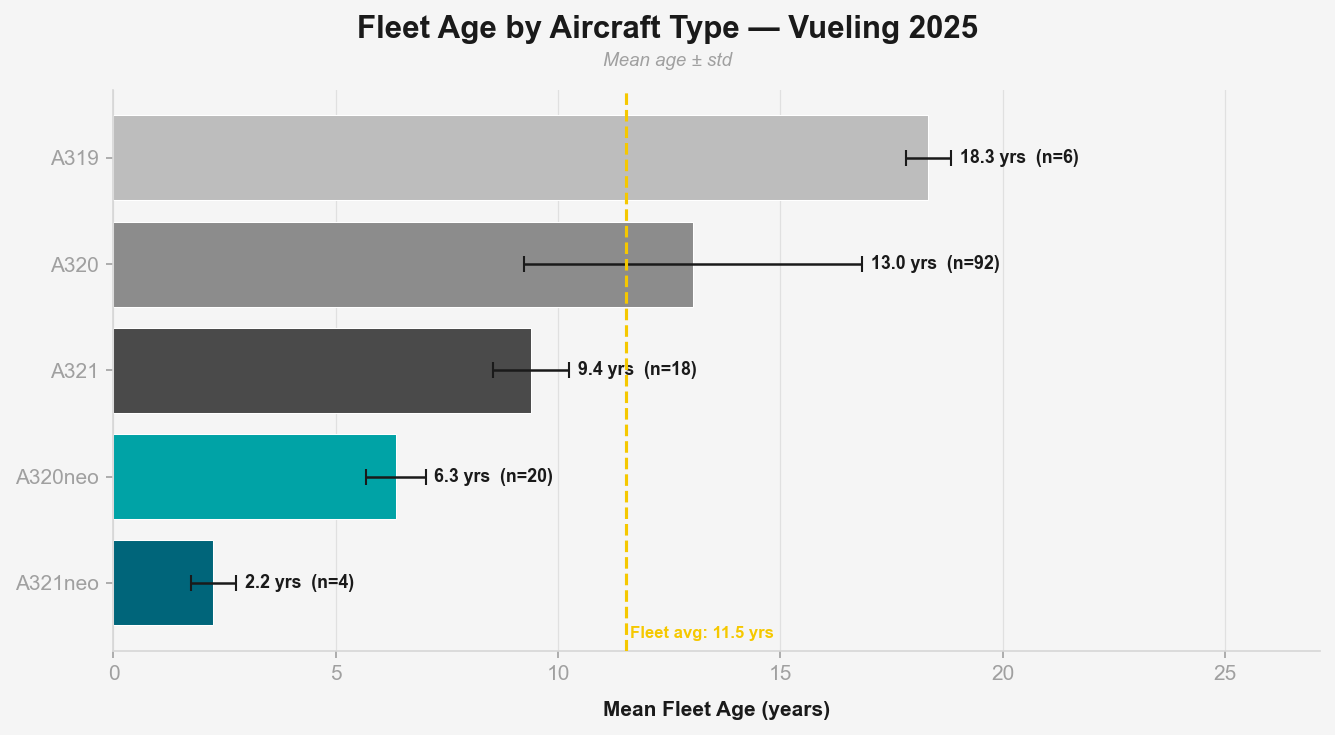

In [15]:
# ── Mean age per ICAO type + plot ─────────────────────────────────────────────
mean_age = (df_fleet.groupby('icao')['age']
            .agg(['mean','std','count'])
            .rename(columns={'mean':'mean_age','std':'std_age','count':'n'})
            .reset_index()
            .sort_values('mean_age', ascending=True))

mean_age['label'] = mean_age['icao'].map(AC_LABELS)

fig, ax = plt.subplots(figsize=(9, 5))
ax.set_axisbelow(True)
ax.grid(True, axis='x', color='#E0E0E0', linewidth=0.6, zorder=0)
ax.grid(False, axis='y')

bars = ax.barh(mean_age['label'], mean_age['mean_age'],
               xerr=mean_age['std_age'],
               color=[AC_COLORS_A3.get(t, VY['grey']) for t in mean_age['icao']],
               edgecolor='white', linewidth=0.5, zorder=2,
               error_kw=dict(elinewidth=1.2, ecolor=VY['dark'], capsize=4))

# Labels: mean age + fleet count
for _, row in mean_age.iterrows():
    ax.text(row['mean_age'] + row['std_age'] + 0.2,
            list(mean_age['label']).index(row['label']),
            f"{row['mean_age']:.1f} yrs  (n={int(row['n'])})",
            va='center', fontsize=8.5, color=VY['dark'], fontweight='bold')

ax.set_xlabel('Mean Fleet Age (years)')
ax.set_xlim(0, mean_age['mean_age'].max() + mean_age['std_age'].max() + 5)
ax.spines['left'].set_color(VY['light_grey'])
ax.spines['bottom'].set_color(VY['light_grey'])

# overall fleet mean age line
overall_mean = df_fleet['age'].mean()
ax.axvline(overall_mean, color=VY['yellow'], lw=1.5, ls='--', zorder=4)
ax.text(overall_mean + 0.1, -0.55, f'Fleet avg: {overall_mean:.1f} yrs',
        color=VY['yellow'], fontsize=8, fontweight='bold', va='bottom')

styled_title(fig, 'Fleet Age by Aircraft Type — Vueling 2025',
             'Mean age ± std')
fig.tight_layout(rect=[0,0.01,1,0.91])
fig.savefig('../0. Data/Figures/fleet_age.pdf', bbox_inches='tight')
plt.show()

---

In [16]:
df = pd.read_csv('../0. Data/1 Year Flight Data/vueling_flights_feb25-feb26.csv')
df['haul'] = df['total_distance_km'].apply(lambda x: 'Short-haul' if x < 1500 else 'Mid-haul' if x < 4000 else 'Long-haul')
print(df['haul'].value_counts(normalize=False))

haul
Short-haul    187670
Mid-haul       35055
Name: count, dtype: int64


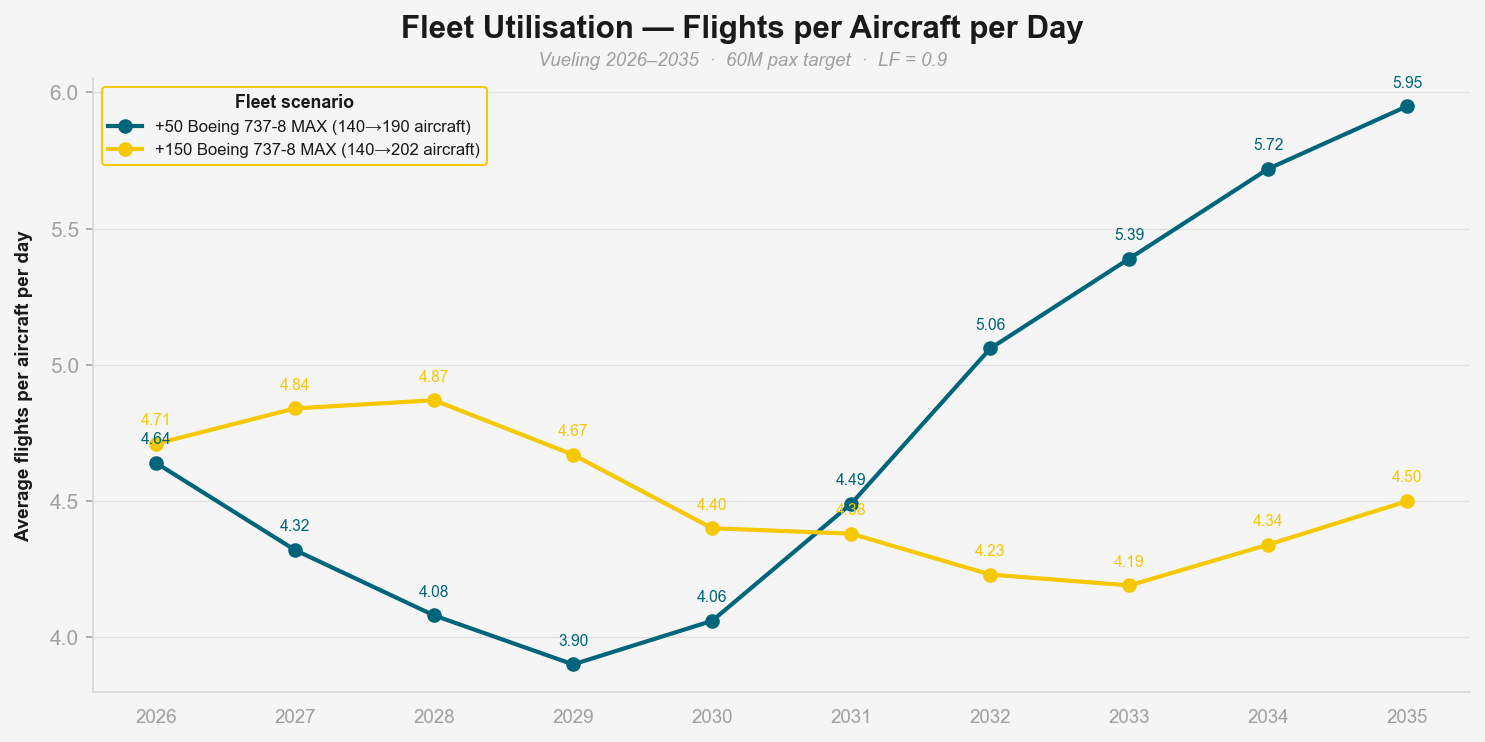

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.legend as mlegend

s50  = pd.read_csv('../0. Data/sanity_check_50_new_boeing.csv',  index_col=0)
s150 = pd.read_csv('../0. Data/sanity_check_150_new_boeing.csv', index_col=0)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(s50.index,  s50['flights_per_ac_per_day'],
        color=VY['deep_teal'], lw=2, marker='o', ms=6, zorder=3,
        label='+50 Boeing 737-8 MAX (140→190 aircraft)')
ax.plot(s150.index, s150['flights_per_ac_per_day'],
        color=VY['yellow'], lw=2, marker='o', ms=6, zorder=3,
        label='+150 Boeing 737-8 MAX (140→202 aircraft)')

# Industry benchmark band
# ax.axhspan(4, 7, color=VY['teal'], alpha=0.06, zorder=0,
#            label='Typical short-haul range (4–7 flights/ac/day)')
# ax.axhline(4, color=VY['teal'],  lw=0.8, ls='--', alpha=0.5, zorder=1)
# ax.axhline(7, color=VY['teal'],  lw=0.8, ls='--', alpha=0.5, zorder=1)

# Value labels
for df, color in [(s50, VY['deep_teal']), (s150, VY['yellow'])]:
    for year, row in df.iterrows():
        ax.text(year, row['flights_per_ac_per_day'] + 0.07,
                f"{row['flights_per_ac_per_day']:.2f}",
                ha='center', fontsize=7.5, color=color)

ax.set_axisbelow(True)
ax.grid(True, axis='y', zorder=0)
ax.grid(False, axis='x')
ax.spines['left'].set_color(VY['light_grey'])
ax.spines['bottom'].set_color(VY['light_grey'])

ax.set_xticks(s50.index)
ax.set_xticklabels(s50.index.astype(int), fontsize=9)
ax.tick_params(axis='x', length=0, pad=8)
ax.set_ylabel('Average flights per aircraft per day', fontsize=9)

leg = ax.legend(fontsize=8, title='Fleet scenario', title_fontsize=8.5,
                loc='upper left')
style_legend(leg)

styled_title(fig,
    'Fleet Utilisation — Flights per Aircraft per Day',
    r'Vueling 2026–2035  ·  60M pax target  ·  LF = 0.9')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('../0. Data/Figures/sanity_fleet_utilisation.pdf', bbox_inches='tight', dpi=150)
plt.show()